# Oracle Model — Accuracy-Oriented Random Forest

A high-accuracy Random Forest trained on all completed W&B runs to act as simulated ground truth for convergence simulation. Unlike the acquisition surrogate (which maximizes tree diversity for σ̂ signal), the oracle maximizes predictive accuracy.

**Final hyperparams:**

| Parameter | Value |
|-----------|-------|
| `n_estimators` | 1024 |
| `max_features` | `None` (all features) |
| `max_samples` | `None` (full bootstrap) |
| `min_samples_leaf` | 3 |

In [1]:
import os
import itertools
import numpy as np
import pandas as pd
import polars as pl
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn

from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import FunctionTransformer
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.pipeline import Pipeline

from src.visualization import set_themes
from src.utils import get_kernel_id
from src.utils.config import parse_score_metric, Log10Transformer, Log2Transformer
from src.utils.styled_tables import data_preview_styled, style_run_density
from IPython.display import Markdown, display

from typing import List

set_themes()
pl.Config.set_tbl_rows(20)
sklearn.set_config(transform_output="pandas")

print("Current kernel:", get_kernel_id())

Current kernel: ab12864e-fe29-4802-af47-4733b7581c11


## Configuration

Define the target metric and the discrete hyperparameter space to enumerate over.

In [9]:
run_summary_file = "wandb/summary.parquet"

# Target metric spec — same format as model_based_parse_parameters
# Single metric: "epoch/test_recall@20"
# Weighted composite: "epoch/test_recall@20:0.7 epoch/test_ndcg@20:0.3"
target_spec = "epoch/test_recall@20"
parsed_target = parse_score_metric(target_spec)
target_metric = "target"

# UCB exploration weight — for oracle ESM computation
beta = 1.0

# Hyperparameter columns to use as surrogate features.
# parameter_space (the list of discrete values per column) is derived automatically
# from completed runs in the Data Loading step below.
feature_names = [
    "embedding_dimension",
    "shuffle",
    "l1_regularization",
    "l2_regularization",
    "embedding_dropout_rate",
]

## Data Loading

Load completed runs from the local parquet cache produced by `wandb/sync.py`.

In [10]:
experiment_runs = pl.read_parquet(run_summary_file)
experiment_runs = experiment_runs.filter(pl.col("model") == "matrix_factorization")

# Compute target: best weighted composite score across epochs
# (same logic as model_based_parse_parameters in src/utils/config.py)
score_expression = sum(pl.col(m) * w for m, w in parsed_target.items())
experiment_runs = experiment_runs.with_columns(
    score_expression.list.max().alias(target_metric)
)

# Derive parameter_space from unique observed values per feature column
parameter_space = {}
for col in feature_names:
    unique_vals = sorted(experiment_runs[col].drop_nulls().unique().to_list())
    parameter_space[col] = unique_vals

total_space_size = 1
for values in parameter_space.values():
    total_space_size *= len(values)

print(f"Loaded {len(experiment_runs):,} runs")
print(f"Total joint parameter space: {total_space_size:,} configurations")
for col, vals in parameter_space.items():
    print(f"  {col}: {vals}")

Loaded 3,410 runs
Total joint parameter space: 20,000 configurations
  embedding_dimension: [2, 4, 8, 16, 32, 64, 128, 256, 512, 1024]
  shuffle: [False, True]
  l1_regularization: [0.0, 1e-10, 1e-09, 1e-08, 1e-07, 1e-06, 1e-05, 0.0001, 0.001, 0.01]
  l2_regularization: [0.0, 1e-10, 1e-09, 1e-08, 1e-07, 1e-06, 1e-05, 0.0001, 0.001, 0.01]
  embedding_dropout_rate: [0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]


In [11]:
top_runs = (
    experiment_runs
    .sort(pl.col(target_metric), descending=True)
    .select(["run_id", "run_name", *feature_names, target_metric])
    .to_pandas()
)

data_preview_styled(
    top_runs,
    caption="Top runs by target score — best epoch test_recall@20 across all completed runs"
)

,run_id,run_name,embedding_dimension,shuffle,l1_regularization,l2_regularization,embedding_dropout_rate,target
0,kl4wqlfj,fallen-frost-6124,1024,False,1e-07,1e-07,0,0.0510807
1,06bqx7vi,spring-vortex-3451,512,False,1e-07,1e-07,0,0.0508812
2,ppnmplwp,light-vortex-4549,512,False,1e-07,1e-07,0,0.0508023
3,3f5jmpwt,crisp-sponge-5704,512,False,1e-07,1e-07,0,0.0508023
4,tc5m18b1,northern-wildflower-4878,512,False,1e-07,1e-07,0,0.0507871
5,th4pgbno,dark-elevator-3601,512,False,1e-07,1e-07,0,0.0507706
6,0287jiys,visionary-dust-4876,512,False,1e-07,1e-07,0,0.050766
7,xznge89i,zesty-mountain-5325,512,False,1e-07,1e-07,0,0.0507626
8,yir89nn4,eager-lake-6123,256,False,1e-07,1e-07,0,0.0507551
9,w1trw3q4,neat-field-5327,512,False,1e-07,1e-07,0,0.0507536


## Data Preparation

Extract X (hyperparameter features) and y (best checkpoint score) from the loaded runs. Rows with missing target values are dropped.

- `shuffle` is cast to `Boolean` for consistency with the convergence simulation notebook
- `l1_regularization` and `l2_regularization` are kept in raw scale here. The **log₁₀ transform** is applied inside the sklearn `Pipeline`. `Log2Transformer` appends `log2(embedding_dimension)` as an additional feature at transform time, so the Polars data only needs the original 5 columns.

In [12]:
# Keep only rows that have all feature columns and the target metric
required_cols = feature_names + [target_metric]
full_dataframe = experiment_runs.select(required_cols).drop_nulls()

# Cast shuffle to Boolean for consistency with convergence simulation
full_dataframe = full_dataframe.with_columns(pl.col("shuffle").cast(pl.Boolean))

full_features = full_dataframe.select(feature_names).to_numpy()
full_target = full_dataframe[target_metric].to_numpy()

print(f"Training samples: {len(full_target):,}")
print(f"Target range:  [{full_target.min():.4f}, {full_target.max():.4f}]")
print(f"Target mean:   {full_target.mean():.4f}  ±  {full_target.std():.4f}")

Training samples: 3,410
Target range:  [0.0004, 0.0511]
Target mean:   0.0217  ±  0.0193


### Run Density per Parameter Region

Before choosing a leave-one-region-out holdout, check how many runs exist per value of each feature. A good holdout region should have:
- Enough runs to make the evaluation meaningful (≥ 10)
- Cover a range of target scores (not all zeros or all best)
- Not be at the extreme of the space (otherwise the surrogate has no neighbours to generalise from)

In [13]:
# Run density per parameter region — count, mean, std, min, max of target score
from IPython.display import display

for col in feature_names:
    summary = (
        full_dataframe
        .group_by(col)
        .agg(
            pl.len().alias("n_runs"),
            pl.col(target_metric).mean().alias("mean_score"),
            pl.col(target_metric).std().alias("std_score"),
            pl.col(target_metric).min().alias("min_score"),
            pl.col(target_metric).max().alias("max_score"),
        )
        .sort(col)
    )
    display(style_run_density(
        summary.to_pandas(),
        caption=f"Run density — {col}",
        descending_columns=["n_runs", "mean_score", "min_score", "max_score"],
        ascending_columns=["std_score"],
    ))

,embedding_dimension,n_runs,mean_score,std_score,min_score,max_score
0,2,338,0.013443,0.0118992,0.000425755,0.0292629
1,4,293,0.0200285,0.0158695,0.000413417,0.0374408
2,8,276,0.0235321,0.0184333,0.000449044,0.0434386
3,16,261,0.0229431,0.0195534,0.000412689,0.0472051
4,32,273,0.0232647,0.0201828,0.000411988,0.0490338
5,64,361,0.0234604,0.0205648,0.000410302,0.0497937
6,128,487,0.0226751,0.0207202,0.000437045,0.0507021
7,256,363,0.0233303,0.0203385,0.000415255,0.0507551
8,512,348,0.0223596,0.0201198,0.000419744,0.0508812
9,1024,410,0.0222227,0.0200036,0.000398079,0.0510807


,shuffle,n_runs,mean_score,std_score,min_score,max_score
0,False,2272,0.0214743,0.0197549,0.000398079,0.0510807
1,True,1138,0.0222585,0.0183199,0.000410302,0.0500979


,l1_regularization,n_runs,mean_score,std_score,min_score,max_score
0,0,1320,0.028931,0.0160959,0.00053644,0.0494515
1,1e-10,62,0.038684,0.00441301,0.0247856,0.0429082
2,1e-09,329,0.0323038,0.0151901,0.00165781,0.049774
3,1e-08,313,0.0318416,0.015683,0.00163111,0.0501882
4,1e-07,347,0.0352187,0.0165576,0.000738772,0.0510807
5,1e-06,295,0.000828726,0.000143465,0.000398079,0.00146874
6,1e-05,306,0.000670791,0.000101764,0.000413417,0.000980718
7,0.0001,298,0.000594325,4.60195e-05,0.000508673,0.00075964
8,0.001,72,0.000634661,2.9106e-05,0.000571359,0.000725075
9,0.01,68,0.000655063,4.09864e-05,0.000600912,0.000841356


,l2_regularization,n_runs,mean_score,std_score,min_score,max_score
0,0,1345,0.0254883,0.0180393,0.000508673,0.0481629
1,1e-10,56,0.0384051,0.00491479,0.0236655,0.0431684
2,1e-09,294,0.0258825,0.0192037,0.000521569,0.0482935
3,1e-08,303,0.0266934,0.0192814,0.000521914,0.0483897
4,1e-07,337,0.0301132,0.0211946,0.000517333,0.0510807
5,1e-06,312,0.0262776,0.0202885,0.000539916,0.0457204
6,1e-05,309,0.00881289,0.00885273,0.000413417,0.0261704
7,0.0001,315,0.00244037,0.00174603,0.000398079,0.0081746
8,0.001,71,0.000664741,7.17899e-05,0.00053644,0.00082273
9,0.01,68,0.00152737,0.000407259,0.000760497,0.00239232


,embedding_dropout_rate,n_runs,mean_score,std_score,min_score,max_score
0,0,2575,0.0199577,0.0196509,0.000398079,0.0510807
1,0.1,60,0.0383361,0.00546677,0.0219445,0.0437118
2,0.2,58,0.0383097,0.00632784,0.0197022,0.0449339
3,0.3,60,0.0382748,0.00644093,0.0206895,0.0448783
4,0.4,360,0.0218636,0.0200383,0.000486882,0.0470823
5,0.5,63,0.0370134,0.00727223,0.0165025,0.0437209
6,0.6,60,0.034982,0.00756476,0.0171414,0.0431936
7,0.7,58,0.0324964,0.00731701,0.0156488,0.0407066
8,0.8,58,0.0269155,0.00681717,0.011032,0.0352224
9,0.9,58,0.00279929,0.00084473,0.00194933,0.00576348


## Oracle Model Training

Fit a **Random Forest Regressor** with accuracy-oriented hyperparams. The oracle serves as simulated ground truth for convergence simulation.

- `max_features=None` — each tree sees all features (no feature subsampling)
- `max_samples=None` — full bootstrap (default, each tree sees ~63% of samples)
- `n_estimators=1024` — enough trees for stable predictions
- `min_samples_leaf=1` — deep trees for maximum accuracy

`oob_score=True` gives an out-of-bag R² estimate without needing a held-out split.

OOB R²: 0.9989


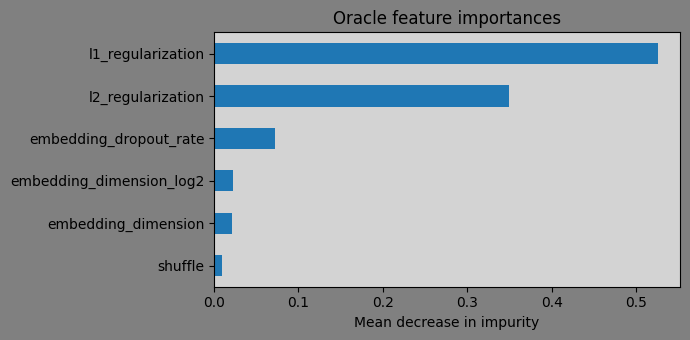

,feature,importance
0,l1_regularization,0.525891
1,l2_regularization,0.349424
2,embedding_dropout_rate,0.072426
3,embedding_dimension_log2,0.0219358
4,embedding_dimension,0.0214333
5,shuffle,0.00888996


In [14]:
# Preprocess features to add log-transformed versions for embedding_dimension, l1_regularization, and l2_regularization
preprocessor = ColumnTransformer(
    transformers=[
        ("shuffle", FunctionTransformer(lambda x: x, validate=True, feature_names_out="one-to-one"), ["shuffle"]),  # keep shuffle as is (Boolean)
        ("log2", Log2Transformer(inline_replace=False), ["embedding_dimension"]),  # embedding_dimension log2 as additional features
        ("log10", Log10Transformer(inline_replace=True), ["l1_regularization", "l2_regularization"]),  # l1 and l2 regularization
    ],
    remainder="passthrough",  
    verbose_feature_names_out=False
)

# Oracle: accuracy-oriented RF using ColumnTransformer for preprocessing
oracle = Pipeline([
    ("preprocess", preprocessor),
    ("random_forest", RandomForestRegressor(
        n_estimators=1024,
        max_features=None,
        max_samples=None,
        min_samples_leaf=3,
        oob_score=True,
        n_jobs=-1,
        random_state=42,
    )),
])

oracle.fit(full_dataframe.select(feature_names), full_target)
print(f"OOB R²: {oracle.named_steps['random_forest'].oob_score_:.4f}")

# Feature importances — derive labels from ColumnTransformer output order
transformed_sample: pd.DataFrame = preprocessor.transform(full_dataframe.select(feature_names).head(1))
feature_labels = transformed_sample.columns.tolist()
fig, ax = plt.subplots(figsize=(7, 3.5))
feature_importances = pd.Series(
    oracle.named_steps["random_forest"].feature_importances_,
    index=feature_labels,
).sort_values(ascending=True)
feature_importances.plot.barh(ax=ax)
ax.set_xlabel("Mean decrease in impurity")
ax.set_title("Oracle feature importances")
plt.tight_layout()
plt.show()

importance_dataframe = feature_importances.reset_index()
importance_dataframe.columns = ["feature", "importance"]
importance_dataframe = importance_dataframe.sort_values("importance", ascending=False).reset_index(drop=True)
display(style_run_density(
    importance_dataframe,
    caption="Oracle — feature importances (mean decrease in impurity)",
    descending_columns=["importance"],
))

## Full Parameter Space — Explored vs. Unexplored

Enumerate the full 20,000-cell combinatorial hyperparameter grid. *Explored* cells are those with at least one completed run; *unexplored* cells have none. The oracle predicts μ̂ and σ̂ for every cell via per-tree predictions (1024 trees).

In [15]:
# Build full grid and compute oracle predictions
all_combinations = list(itertools.product(*parameter_space.values()))
full_grid = pl.DataFrame(
    {col: [row[i] for row in all_combinations] for i, col in enumerate(feature_names)}
)
full_grid = full_grid.with_columns(pl.col("shuffle").cast(pl.Boolean))

# Tag explored cells
explored_dataframe = (
    full_dataframe
    .group_by(feature_names)
    .agg(pl.col(target_metric).mean().alias(f"observed_{target_metric}"))
)
explored_keys = set(
    tuple(row) for row in explored_dataframe.select(feature_names).to_numpy().tolist()
)
full_grid = full_grid.with_columns(
    pl.struct(feature_names)
    .map_elements(lambda s: tuple(s[c] for c in feature_names) in explored_keys, return_dtype=pl.Boolean)
    .alias("explored")
)

# Compute μ̂ and σ̂ via per-tree predictions
grid_features = full_grid.select(feature_names)
oracle_random_forests = oracle.named_steps["random_forest"]
oracle_preprocess = oracle.named_steps["preprocess"]
grid_transformed = oracle_preprocess.transform(grid_features)
tree_predictions = np.stack([tree.predict(grid_transformed.to_numpy()) for tree in oracle_random_forests.estimators_], axis=1)
mu_hat = tree_predictions.mean(axis=1)
sigma_hat = tree_predictions.std(axis=1)

full_grid = full_grid.with_columns([
    pl.Series("mu_hat", mu_hat),
    pl.Series("sigma_hat", sigma_hat),
])

# Join observed metrics for explored cells
full_grid = full_grid.join(
    explored_dataframe.rename({f"observed_{target_metric}": "explored_mu"}),
    on=feature_names,
    how="left",
)

n_explored = full_grid["explored"].sum()
n_total = len(full_grid)
print(f"Total cells:  {n_total:,}")
print(f"Explored:     {n_explored:,}  ({n_explored / n_total * 100:.2f}%)")
print(f"Unexplored:   {n_total - n_explored:,}  ({(n_total - n_explored) / n_total * 100:.2f}%)")

Total cells:  20,000
Explored:     1,516  (7.58%)
Unexplored:   18,484  (92.42%)


### Deconfounded Parameter Marginals

Average oracle prediction (μ̂) and uncertainty (σ̂) per value of each hyperparameter. Unlike the raw `mean_score` in the run density table, these marginal averages are *deconfounded* — they reflect what the oracle predicts for each parameter value averaged over all 20,000 configurations, not just the limited set of explored runs.

In [16]:
# Deconfounded parameter marginals — μ̂ and σ̂ per feature value
from IPython.display import display

for column_name in feature_names:
    raw = (
        full_dataframe
        .group_by(column_name)
        .agg(
            pl.len().alias("n_runs"),
            pl.col(target_metric).mean().alias("mean_score"),
        )
    )

    surrogate = (
        full_grid
        .group_by(column_name)
        .agg(
            pl.col("mu_hat").mean().alias("oracle_mean"),
            pl.col("sigma_hat").mean().alias("oracle_sigma"),
        )
    )

    summary = raw.join(surrogate, on=column_name).with_columns(
        (pl.col("oracle_mean") - pl.col("mean_score")).alias("diff"),
    ).sort(column_name)

    display(style_run_density(
        summary.to_pandas(),
        caption=f"Oracle marginal means — {column_name}",
        ascending_columns=["diff"],
        descending_columns=["n_runs", "mean_score", "oracle_mean", "oracle_sigma"],
    ))

,embedding_dimension,n_runs,mean_score,oracle_mean,oracle_sigma,diff
0,2,338,0.013443,0.00690044,0.000310745,-0.00654259
1,4,293,0.0200285,0.00928381,0.000326323,-0.0107447
2,8,276,0.0235321,0.0111938,0.000338172,-0.0123383
3,16,261,0.0229431,0.0119979,0.000375204,-0.0109452
4,32,273,0.0232647,0.0123509,0.00032351,-0.0109138
5,64,361,0.0234604,0.0126334,0.000259369,-0.0108269
6,128,487,0.0226751,0.0128265,0.000224128,-0.0098486
7,256,363,0.0233303,0.0127528,0.000232148,-0.0105775
8,512,348,0.0223596,0.0124586,0.000315715,-0.00990101
9,1024,410,0.0222227,0.012251,0.000375761,-0.00997168


,shuffle,n_runs,mean_score,oracle_mean,oracle_sigma,diff
0,False,2272,0.0214743,0.0110798,0.000328212,-0.0103945
1,True,1138,0.0222585,0.0118501,0.000288003,-0.0104084


,l1_regularization,n_runs,mean_score,oracle_mean,oracle_sigma,diff
0,0,1320,0.028931,0.0223155,0.000568506,-0.00661549
1,1e-10,62,0.038684,0.0220453,0.000599348,-0.0166387
2,1e-09,329,0.0323038,0.0220577,0.000587632,-0.0102461
3,1e-08,313,0.0318416,0.0220912,0.000604317,-0.00975035
4,1e-07,347,0.0352187,0.0227903,0.000614268,-0.0124284
5,1e-06,295,0.000828726,0.00080638,3.77435e-05,-2.23461e-05
6,1e-05,306,0.000670791,0.000661789,1.9867e-05,-9.00154e-06
7,0.0001,298,0.000594325,0.00059736,1.74528e-05,3.03468e-06
8,0.001,72,0.000634661,0.000634334,1.53389e-05,-3.27863e-07
9,0.01,68,0.000655063,0.000649218,1.66017e-05,-5.84453e-06


,l2_regularization,n_runs,mean_score,oracle_mean,oracle_sigma,diff
0,0,1345,0.0254883,0.0168533,0.000369499,-0.00863496
1,1e-10,56,0.0384051,0.0168799,0.000375302,-0.0215252
2,1e-09,294,0.0258825,0.0168832,0.000374061,-0.00899931
3,1e-08,303,0.0266934,0.0169124,0.000376887,-0.00978093
4,1e-07,337,0.0301132,0.0179451,0.00056239,-0.012168
5,1e-06,312,0.0262776,0.0174549,0.000418674,-0.00882266
6,1e-05,309,0.00881289,0.00817903,0.000314709,-0.000633853
7,0.0001,315,0.00244037,0.00180191,0.0001718,-0.00063846
8,0.001,71,0.000664741,0.000642571,2.72857e-05,-2.21701e-05
9,0.01,68,0.00152737,0.00109672,9.04678e-05,-0.000430647


,embedding_dropout_rate,n_runs,mean_score,oracle_mean,oracle_sigma,diff
0,0,2575,0.0199577,0.01354,0.000149317,-0.00641777
1,0.1,60,0.0383361,0.013495,0.000211924,-0.024841
2,0.2,58,0.0383097,0.0134409,0.000226502,-0.0248688
3,0.3,60,0.0382748,0.0131576,0.000274008,-0.0251172
4,0.4,360,0.0218636,0.0129811,0.00027718,-0.00888248
5,0.5,63,0.0370134,0.0128352,0.000313395,-0.0241782
6,0.6,60,0.034982,0.0122729,0.000606856,-0.0227091
7,0.7,58,0.0324964,0.0111811,0.00040801,-0.0213153
8,0.8,58,0.0269155,0.00953337,0.000505311,-0.0173822
9,0.9,58,0.00279929,0.00221196,0.000108571,-0.000587333


### σ̂ Validation — Explored vs. Unexplored Cells

Compare the oracle's predicted mean (μ̂), uncertainty (σ̂), and UCB between explored and unexplored cells. The oracle should have tight σ̂ everywhere (σ̂ ratio < 3x), confirming it is confident where it has training data — unlike the acquisition surrogate which deliberately maximizes σ̂ separation for exploration.

Explored cells:   μ̂ = 0.019589 ± 0.019370   σ̂ = 0.000283 ± 0.000365   UCB = 0.019871 ± 0.019530
Unexplored cells: μ̂ = 0.010799 ± 0.016155   σ̂ = 0.000310 ± 0.000573   UCB = 0.011109 ± 0.016502
σ̂ ratio (unexplored / explored): 1.10x
Target: oracle σ̂ should be tight (ratio < 3x)


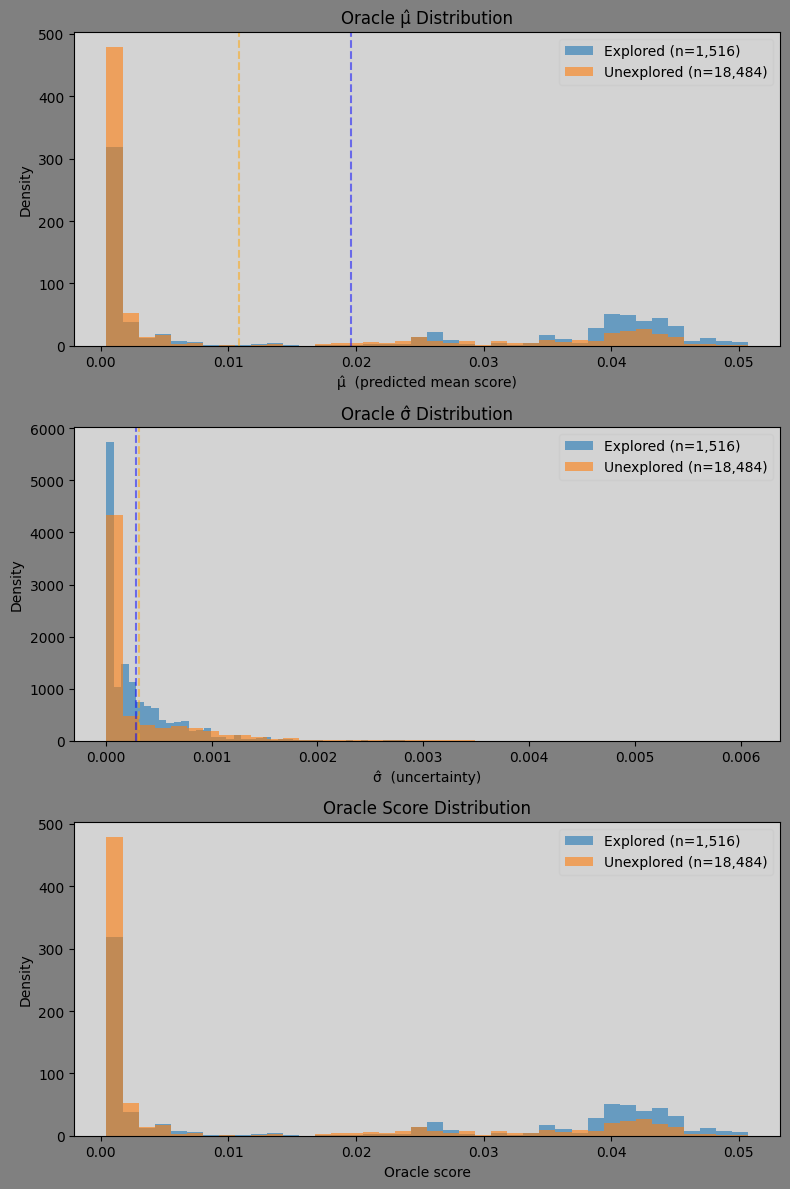

In [17]:
# σ̂ validation — explored vs unexplored cells
explored_mu_vector = full_grid.filter(pl.col("explored"))["mu_hat"].to_numpy()
unexplored_mu_vector = full_grid.filter(~pl.col("explored"))["mu_hat"].to_numpy()
explored_sigma_vector = full_grid.filter(pl.col("explored"))["sigma_hat"].to_numpy()
unexplored_sigma_vector = full_grid.filter(~pl.col("explored"))["sigma_hat"].to_numpy()

explored_ucb_vector = explored_mu_vector + beta * explored_sigma_vector
unexplored_ucb_vector = unexplored_mu_vector + beta * unexplored_sigma_vector

sigma_ratio = unexplored_sigma_vector.mean() / explored_sigma_vector.mean()

print(f"Explored cells:   μ̂ = {explored_mu_vector.mean():.6f} ± {explored_mu_vector.std():.6f}   σ̂ = {explored_sigma_vector.mean():.6f} ± {explored_sigma_vector.std():.6f}   UCB = {explored_ucb_vector.mean():.6f} ± {explored_ucb_vector.std():.6f}")
print(f"Unexplored cells: μ̂ = {unexplored_mu_vector.mean():.6f} ± {unexplored_mu_vector.std():.6f}   σ̂ = {unexplored_sigma_vector.mean():.6f} ± {unexplored_sigma_vector.std():.6f}   UCB = {unexplored_ucb_vector.mean():.6f} ± {unexplored_ucb_vector.std():.6f}")
print(f"σ̂ ratio (unexplored / explored): {sigma_ratio:.2f}x")
print(f"Target: oracle σ̂ should be tight (ratio < 3x)")

fig, axes = plt.subplots(3, 1, figsize=(8, 12))

axes[0].hist(explored_mu_vector, bins=40, alpha=0.6, density=True, label=f"Explored (n={len(explored_mu_vector):,})")
axes[0].hist(unexplored_mu_vector, bins=40, alpha=0.6, density=True, label=f"Unexplored (n={len(unexplored_mu_vector):,})")
axes[0].axvline(explored_mu_vector.mean(), color='blue', linestyle='--', alpha=0.5)
axes[0].axvline(unexplored_mu_vector.mean(), color='orange', linestyle='--', alpha=0.5)
axes[0].set_xlabel("μ̂  (predicted mean score)")
axes[0].set_ylabel("Density")
axes[0].set_title("Oracle μ̂ Distribution")
axes[0].legend()

axes[1].hist(explored_sigma_vector, bins=40, alpha=0.6, density=True, label=f"Explored (n={len(explored_sigma_vector):,})")
axes[1].hist(unexplored_sigma_vector, bins=40, alpha=0.6, density=True, label=f"Unexplored (n={len(unexplored_sigma_vector):,})")
axes[1].axvline(explored_sigma_vector.mean(), color='blue', linestyle='--', alpha=0.5)
axes[1].axvline(unexplored_sigma_vector.mean(), color='orange', linestyle='--', alpha=0.5)
axes[1].set_xlabel("σ̂  (uncertainty)")
axes[1].set_ylabel("Density")
axes[1].set_title("Oracle σ̂ Distribution")
axes[1].legend()

axes[2].hist(explored_mu_vector, bins=40, alpha=0.6, density=True, label=f"Explored (n={len(explored_mu_vector):,})")
axes[2].hist(unexplored_mu_vector, bins=40, alpha=0.6, density=True, label=f"Unexplored (n={len(unexplored_mu_vector):,})")
axes[2].set_xlabel("Oracle score")
axes[2].set_ylabel("Density")
axes[2].set_title("Oracle Score Distribution")
axes[2].legend()

plt.tight_layout()
plt.show()

## Exploration Metric

### ESM — Exploration Saturation Metric

Quantifies how much of the predicted high-performing region has been explored:

$$\text{ESM} = \frac{\mu_{\text{best, observed}}}{\hat{\mu}_{\text{max}} + \beta \cdot \hat{\sigma}_{\text{max}}} \times 100\%$$

- **μ_best, observed** — highest observed score among completed runs
- **best oracle UCB** — highest predicted score + uncertainty across all grid cells
- ESM ≈ 100% → the oracle sees no unexplored configuration that could beat the best observed run

In [18]:
# ESM — Exploration Saturation Metric
mu_best_observed = explored_dataframe[f"observed_{target_metric}"].max()

grid_with_ucb = full_grid.with_columns(
    (pl.col("mu_hat") + beta * pl.col("sigma_hat")).alias("ucb")
).sort("ucb", descending=True)
best_cell = grid_with_ucb.head(1)

best_mu_hat = best_cell["mu_hat"].item()
best_sigma_hat = best_cell["sigma_hat"].item()
best_ucb = best_cell["ucb"].item()

esm = mu_best_observed / best_ucb * 100 if best_ucb > 0 else 0.0

print(f"Best observed score (mu_best): {mu_best_observed:.6f}")
print(f"Best grid UCB:        mu_hat={best_mu_hat:.6f}  sigma_hat={best_sigma_hat:.6f}  UCB={best_ucb:.6f}")
print()

nines = 0
if esm >= 90:
    nines = 1
if esm >= 99:
    nines = 2
if esm >= 99.9:
    nines = 3
print(f"ESM = {esm:.6f}%  ({nines} nines)")
if esm >= 99.9:
    print("  → Above 99.9% — Exploration appears saturated")
elif esm >= 99:
    print("  → Above 99% — Approaching saturation")
elif esm >= 90:
    print("  → Above 90% — Late exploration stage")
else:
    print("  → Below 90% — Early exploration stage")

# Coverage — what fraction of top-p% predicted configs have been explored?
sorted_by_mu = full_grid.sort("mu_hat", descending=True)
total_cells = len(sorted_by_mu)
coverage_values = {}
for p_threshold in [50, 75, 90, 95]:
    top_k = max(1, int(total_cells * (100 - p_threshold) / 100))
    top_slice = sorted_by_mu.head(top_k)
    explored_count = top_slice["explored"].sum()
    coverage_pct = explored_count / top_k * 100
    coverage_values[f"coverage@{p_threshold}"] = coverage_pct
    print(f"Coverage at p={p_threshold:<4d} (top {100-p_threshold:>2d}% predicted configs): {coverage_pct:.2f}%")

# Stop condition
coverage_75 = coverage_values.get("coverage@75", 0.0)
stop_condition_met = (esm >= 99.9) and (coverage_75 >= 80.0)
SEP = "=" * 50
print(f"\n{SEP}")
print(f"  ESM:          {esm:.4f}%   (threshold >= 99.9%)  {'✓' if esm >= 99.9 else '✗'}")
print(f"  Coverage@75:  {coverage_75:.2f}%    (threshold >= 80.0%)  {'✓' if coverage_75 >= 80.0 else '✗'}")
print(f"{SEP}")
if stop_condition_met:
    print("  → STOP exploration.")
else:
    print("  → CONTINUE exploration.")
print(f"{SEP}")


Best observed score (mu_best): 0.050782
Best grid UCB:        mu_hat=0.050308  sigma_hat=0.000733  UCB=0.051041

ESM = 99.493526%  (2 nines)
  → Above 99% — Approaching saturation
Coverage at p=50   (top 50% predicted configs): 10.46%
Coverage at p=75   (top 25% predicted configs): 13.82%
Coverage at p=90   (top 10% predicted configs): 15.45%
Coverage at p=95   (top  5% predicted configs): 18.00%

  ESM:          99.4935%   (threshold >= 99.9%)  ✗
  Coverage@75:  13.82%    (threshold >= 80.0%)  ✗
  → CONTINUE exploration.


## Model Evaluation — Leave-Cliff-Out

Hold out runs at or across the two performance cliffs (l1=1e-6/1e-7, l2=1e-5/1e-6). This forces the oracle to extrapolate across the performance discontinuities — the hardest test of predictive accuracy.

Train size: 2,301  |  Test size (cliff runs): 1,109
Test target range: [0.0004, 0.0511]

Held-out R²  : 0.9136
Held-out MAE : 0.0029
Spearman ρ   : 0.9473
NDCG@50      : 0.9289
NDCG@100     : 0.9386
NDCG@200     : 0.9704


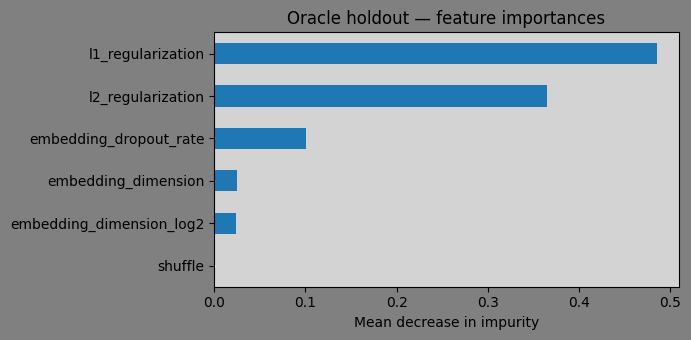

,feature,importance
0,l1_regularization,0.484876
1,l2_regularization,0.364904
2,embedding_dropout_rate,0.101012
3,embedding_dimension,0.0247978
4,embedding_dimension_log2,0.0240178
5,shuffle,0.000392093


In [19]:
# Test set: runs at or across either performance cliff
mask_cliff = (
    full_dataframe["l1_regularization"].is_in([1e-7, 1e-6])
    | full_dataframe["l2_regularization"].is_in([1e-6, 1e-5])
)

train_dataframe = full_dataframe.filter(~mask_cliff)
test_dataframe  = full_dataframe.filter(mask_cliff)

train_features = train_dataframe.select(feature_names).to_numpy()
train_target   = train_dataframe[target_metric].to_numpy()
test_features  = test_dataframe.select(feature_names).to_numpy()
test_target    = test_dataframe[target_metric].to_numpy()

print(f"Train size: {len(train_dataframe):,}  |  Test size (cliff runs): {len(test_dataframe):,}")
print(f"Test target range: [{test_target.min():.4f}, {test_target.max():.4f}]")
print()

oracle_eval = Pipeline([
    ("preprocess", preprocessor),
    ("random_forest", RandomForestRegressor(
        n_estimators=512,
        max_features=None,
        max_samples=None,
        min_samples_leaf=3,
        oob_score=False,
        n_jobs=-1,
        random_state=42,
    )),
])
oracle_eval.fit(train_dataframe.select(feature_names), train_target)
predicted_target = oracle_eval.predict(test_dataframe.select(feature_names))

print(f"Held-out R²  : {r2_score(test_target, predicted_target):.4f}")
print(f"Held-out MAE : {mean_absolute_error(test_target, predicted_target):.4f}")
 
# Rank-based metrics — the simulation only needs correct ordering
from scipy.stats import spearmanr

spearman_rho, _ = spearmanr(test_target, predicted_target)
print(f"Spearman ρ   : {spearman_rho:.4f}")

for k in [50, 100, 200]:
    ideal_order = np.argsort(-test_target)[:k]
    ideal_dcg = sum(
        (2 ** test_target[i] - 1) / np.log2(j + 2) for j, i in enumerate(ideal_order)
    )
    pred_order = np.argsort(-predicted_target)[:k]
    dcg = sum(
        (2 ** test_target[i] - 1) / np.log2(j + 2) for j, i in enumerate(pred_order)
    )
    ndcg = dcg / ideal_dcg if ideal_dcg > 0 else 0.0
    print(f"NDCG@{k:<8d}: {ndcg:.4f}")

# Feature importances — derive labels from ColumnTransformer output order
transformed_sample: pd.DataFrame = preprocessor.transform(test_dataframe.select(feature_names).head(1))
feature_labels = transformed_sample.columns.tolist()
fig, ax = plt.subplots(figsize=(7, 3.5))
feature_importances = pd.Series(
    oracle_eval.named_steps["random_forest"].feature_importances_,
    index=feature_labels,
).sort_values(ascending=True)
feature_importances.plot.barh(ax=ax)
ax.set_xlabel("Mean decrease in impurity")
ax.set_title("Oracle holdout — feature importances")
plt.tight_layout()
plt.show()

importance_dataframe = feature_importances.reset_index()
importance_dataframe.columns = ["feature", "importance"]
importance_dataframe = importance_dataframe.sort_values("importance", ascending=False).reset_index(drop=True)
display(style_run_density(
    importance_dataframe,
    caption="Oracle holdout — feature importances (mean decrease in impurity)",
    descending_columns=["importance"],
))

### Hyperparameter Sweep Results

Full comparison of `max_features`, `max_samples`, and `min_samples_leaf` combinations on the cliff holdout. The chosen config (`all-feat, leaf=3`) balances highest Spearman ρ with strong R².

In [20]:
from scipy.stats import spearmanr
from tqdm import tqdm

candidates = [
    {"max_features": "sqrt", "max_samples": None, "min_samples_leaf": 1, "config": "None, leaf=1"},
    {"max_features": "sqrt", "max_samples": None, "min_samples_leaf": 2, "config": "None, leaf=2"},
    {"max_features": "sqrt", "max_samples": None, "min_samples_leaf": 3, "config": "None, leaf=3"},
    {"max_features": "sqrt", "max_samples": None, "min_samples_leaf": 5, "config": "None, leaf=5"},
    {"max_features": "sqrt", "max_samples": None, "min_samples_leaf": 10, "config": "None, leaf=10"},
    {"max_features": "sqrt", "max_samples": 0.1, "min_samples_leaf": 1, "config": "0.1, leaf=1"},
    {"max_features": "sqrt", "max_samples": 0.1, "min_samples_leaf": 2, "config": "0.1, leaf=2"},
    {"max_features": "sqrt", "max_samples": 0.1, "min_samples_leaf": 3, "config": "0.1, leaf=3"},
    {"max_features": "sqrt", "max_samples": 0.1, "min_samples_leaf": 5, "config": "0.1, leaf=5"},
    {"max_features": "sqrt", "max_samples": 0.1, "min_samples_leaf": 10, "config": "0.1, leaf=10"},
    {"max_features": "sqrt", "max_samples": 0.3, "min_samples_leaf": 1, "config": "0.3, leaf=1"},
    {"max_features": "sqrt", "max_samples": 0.3, "min_samples_leaf": 2, "config": "0.3, leaf=2"},
    {"max_features": "sqrt", "max_samples": 0.3, "min_samples_leaf": 3, "config": "0.3, leaf=3"},
    {"max_features": "sqrt", "max_samples": 0.3, "min_samples_leaf": 5, "config": "0.3, leaf=5"},
    {"max_features": "sqrt", "max_samples": 0.3, "min_samples_leaf": 10, "config": "0.3, leaf=10"},
    {"max_features": None, "max_samples": None, "min_samples_leaf": 1, "config": "all-feat, leaf=1"},
    {"max_features": None, "max_samples": None, "min_samples_leaf": 2, "config": "all-feat, leaf=2"},
    {"max_features": None, "max_samples": None, "min_samples_leaf": 3, "config": "all-feat, leaf=3"},
    {"max_features": None, "max_samples": None, "min_samples_leaf": 5, "config": "all-feat, leaf=5"},
    {"max_features": None, "max_samples": None, "min_samples_leaf": 10, "config": "all-feat, leaf=10"},
]

results = []
for params in tqdm(candidates, desc="Evaluating oracle hyperparams"):
    pipe = Pipeline([
        ("preprocess", preprocessor),
        ("rf", RandomForestRegressor(
            n_estimators=512,
            max_features=params["max_features"],
            max_samples=params["max_samples"],
            min_samples_leaf=params["min_samples_leaf"],
            oob_score=False, n_jobs=-1, random_state=42,
        )),
    ])
    pipe.fit(train_dataframe.select(feature_names), train_target)
    predictions = pipe.predict(test_dataframe.select(feature_names))

    r2 = r2_score(test_target, predictions)
    mae = mean_absolute_error(test_target, predictions)
    rho, _ = spearmanr(test_target, predictions)

    results.append({"config": params["config"], "R2": round(r2, 4), "MAE": round(mae, 6), "Spearman": round(rho, 4)})

comparison_table = pd.DataFrame(results)
data_preview_styled(
    comparison_table.set_index("config"),
    caption="Hyperparameter comparison on cliff holdout (full sweep)",
    max_rows=25,
)

Evaluating oracle hyperparams: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 20/20 [00:16<00:00,  1.25it/s]


,R2,MAE,Spearman
config,,,
"None, leaf=1",0.9148,0.002922,0.9435
"None, leaf=2",0.9169,0.002892,0.9302
"None, leaf=3",0.917,0.002891,0.9252
"None, leaf=5",0.9178,0.002939,0.9165
"None, leaf=10",0.9198,0.003116,0.9206
"0.1, leaf=1",0.9228,0.00324,0.9377
"0.1, leaf=2",0.9195,0.003544,0.9271
"0.1, leaf=3",0.9172,0.003769,0.9263
"0.1, leaf=5",0.907,0.004512,0.9138
